In [2]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


from langchain_anthropic import ChatAnthropic
urls = ["www.anthropic.com/engineering", "openai.com/news/"]
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel

from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict, List, Annotated
import operator
import logging
from dotenv import load_dotenv
load_dotenv()

import structlog

structlog.configure(
    processors=[
        structlog.contextvars.merge_contextvars,
        structlog.processors.add_log_level,
        structlog.processors.StackInfoRenderer(),
        structlog.dev.set_exc_info,
        structlog.processors.TimeStamper(fmt="%Y-%m-%d %H:%M:%S", utc=False),
        structlog.dev.ConsoleRenderer()
    ],
    wrapper_class=structlog.make_filtering_bound_logger(logging.DEBUG),
    context_class=dict,
    logger_factory=structlog.PrintLoggerFactory(),
    cache_logger_on_first_use=False
)

logger = structlog.get_logger(__name__)

urls = ["https://increment.com/", "https://danluu.com/"]


tools = [
    {
        "type": "web_fetch_20260209", 
        "name": "web_fetch",
        "max_uses" : 2 
    },
    {
        "type": "web_search_20260209",
        "name": "web_search",
        "max_uses" : 2 
    }
]


model = ChatAnthropic(model="claude-sonnet-4-6").bind_tools(tools)


class DeepDiveDecision(BaseModel):
    should_deep_dive: bool
    reasoning: str

cheap_model = ChatAnthropic(model="claude-haiku-4-5").with_structured_output(DeepDiveDecision)#.bind_tools(tools)#.with_structured_output(DeepDiveDecision)
synthesize_model = ChatAnthropic(model="claude-haiku-4-5")


def merge_dicts(current: dict, update: dict) -> dict:
    return {**current, **update}


def extract_text(content) -> str:
    """Extract plain text from a LangChain response.content (str or list of blocks)."""
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        return " ".join(
            block.get("text", "") if isinstance(block, dict) else str(block)
            for block in content
            if not isinstance(block, dict) or block.get("type") == "text"
        )
    return str(content)


class ResearchState(TypedDict):
    llm_calls: Annotated[int, operator.add]
    audience_focus: str
    processed_content: Annotated[dict, merge_dicts]
    messages: Annotated[list, operator.add]
    urls: List[str]
    current_url: str
    finished: bool = False


def controller(state: ResearchState) -> ResearchState:
    logger.info("Starting in Controller")
    if(len(state['urls']) == 0):
        return {
            "finished": True
        }

    curr_url = state['urls'][-1]
    remaining = state['urls'][:-1]

    return {
        "current_url": curr_url,
        "urls": remaining,
    }

def research_url(state: ResearchState) -> ResearchState:
    logger.info("Starting research in url")
    response = model.invoke([
        SystemMessage(content=state["audience_focus"]),
        HumanMessage(content=f"Fetch and summarize the content at {state['current_url']}")
    ])

    text = extract_text(response.content)
    logger.info("research_url response", content=text)

    return {
        "processed_content": {state["current_url"]: text},
        "llm_calls": 1,
    }


def research_outer(state: ResearchState) -> ResearchState:
    logger.info("Deeper research")
    response = model.invoke([
        SystemMessage(content=state["audience_focus"]),
        HumanMessage(content=f"Perform deeper research if needed {state['processed_content'].get(state['current_url'])}. Seperate content by comma to append to the main source. Attach sources (e.g [source: www.example.com] )")
    ])
    text = extract_text(response.content)
    existing = state["processed_content"].get(state["current_url"], "")

    logger.info("research_outer response", content=text)
    return {
        "processed_content": {state["current_url"]: existing + text},
        "llm_calls": 1,
    }


def synthesize(state: ResearchState) -> ResearchState:
    logger.info("Synthesizing")

    all_responses = ", ".join([extract_text(content) for content in state["processed_content"].values()])
    response = synthesize_model.invoke([
        SystemMessage(content=state["audience_focus"]),
        HumanMessage(content=f"Synthesize the following content in a newsletter style. Content is separated by commas: {all_responses}")
    ])
    text = extract_text(response.content)
    logger.info("synthesize response", content=text)
    return {
        "processed_content": {"synthesized_content": text},
        "llm_calls": 1,
    }


def decide_to_deep_dive(state: ResearchState):
    current_content = state["processed_content"].get(state["current_url"], "")

    decision: DeepDiveDecision = cheap_model.invoke([
        SystemMessage(content=state["audience_focus"]),
        HumanMessage(content=f"""You just summarized this content: {current_content}

    Should we perform deeper research on this topic, or move on to the next URL?
    Consider: Is the content thin? Are there gaps? Would more detail benefit the audience?""")
    ])
    logger.info("deep dive decision", reasoning=decision.reasoning)

    if decision.should_deep_dive:
        return "research_outer"
    return "controller"


def decide_to_finish(state: ResearchState):
    if state.get("finished"):
          return "synthesize"
    else:
        return "research_url"

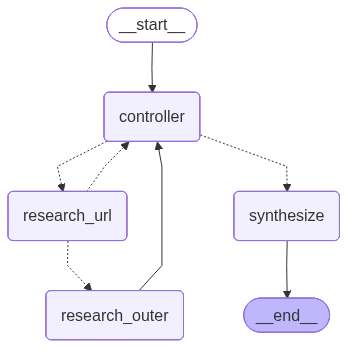

In [3]:
graph = StateGraph(ResearchState)
graph.add_node('controller', controller)
graph.add_node('research_url', research_url)
graph.add_node('research_outer', research_outer)
graph.add_node('synthesize', synthesize)

graph.add_edge(START, "controller")
graph.add_conditional_edges('controller', decide_to_finish, ["research_url", "synthesize"])

graph.add_conditional_edges('research_url', decide_to_deep_dive, ["research_outer", "controller"])

graph.add_edge('research_outer', 'controller')


graph.add_edge('synthesize', END)

compiled = graph.compile()

display(Image(compiled.get_graph().draw_mermaid_png()))